# Iteration 2: Full Autism Pathway Model

This notebook is **Iteration 2** of the discrete-event autism pathway model.

## 0. Model Pathway Diagram (PNG)

![Iteration 2 Autism Pathway](figures/iteration2_model_pathway_human_readable.png)

Image file: `figures/iteration2_model_pathway_human_readable.png`

## 1. Model Scope

- Full end-to-end autism pathway is modeled.
- Simulation time unit is **days**.
- Resources are currently modeled as **24/7 available capacity** (no explicit weekday/weekend calendar constraint).

## 2. Model Assumptions

- Arrivals follow an exponential process (`IAT = 1 / REFERRALS_PER_DAY`).
- Stage service times follow triangular distributions using the configured min/mode/max values.
- Each stage has its own dedicated resource pool (no cross-cover between stages).
- Resource capacity is constant over time (no sickness, leave, shift variation, or overtime).
- No explicit weekend/holiday shutdown; services run continuously in model time.
- No explicit DNA/cancellation/rebooking loop is modeled.
- Patients move forward through the pathway or exit at defined gatekeeping points.
- Branching probabilities are fixed during a run (no time-varying policy changes).
- Patients are served first-come, first-served within each stage resource queue.
- Run-level randomness is controlled by fixed random streams for reproducibility.

## 3. Table of Contents

1. Imports
2. Global Settings and NHS Targets
3. Parameter Meanings
4. Trace Utility
5. Audit Class
6. Experiment Setup
7. Patient Pathway Logic
8. System Resource Setup
9. Single Run Function
10. Quick Trace Test Run
11. Main Results Run
12. 100% Triage Rejection Test

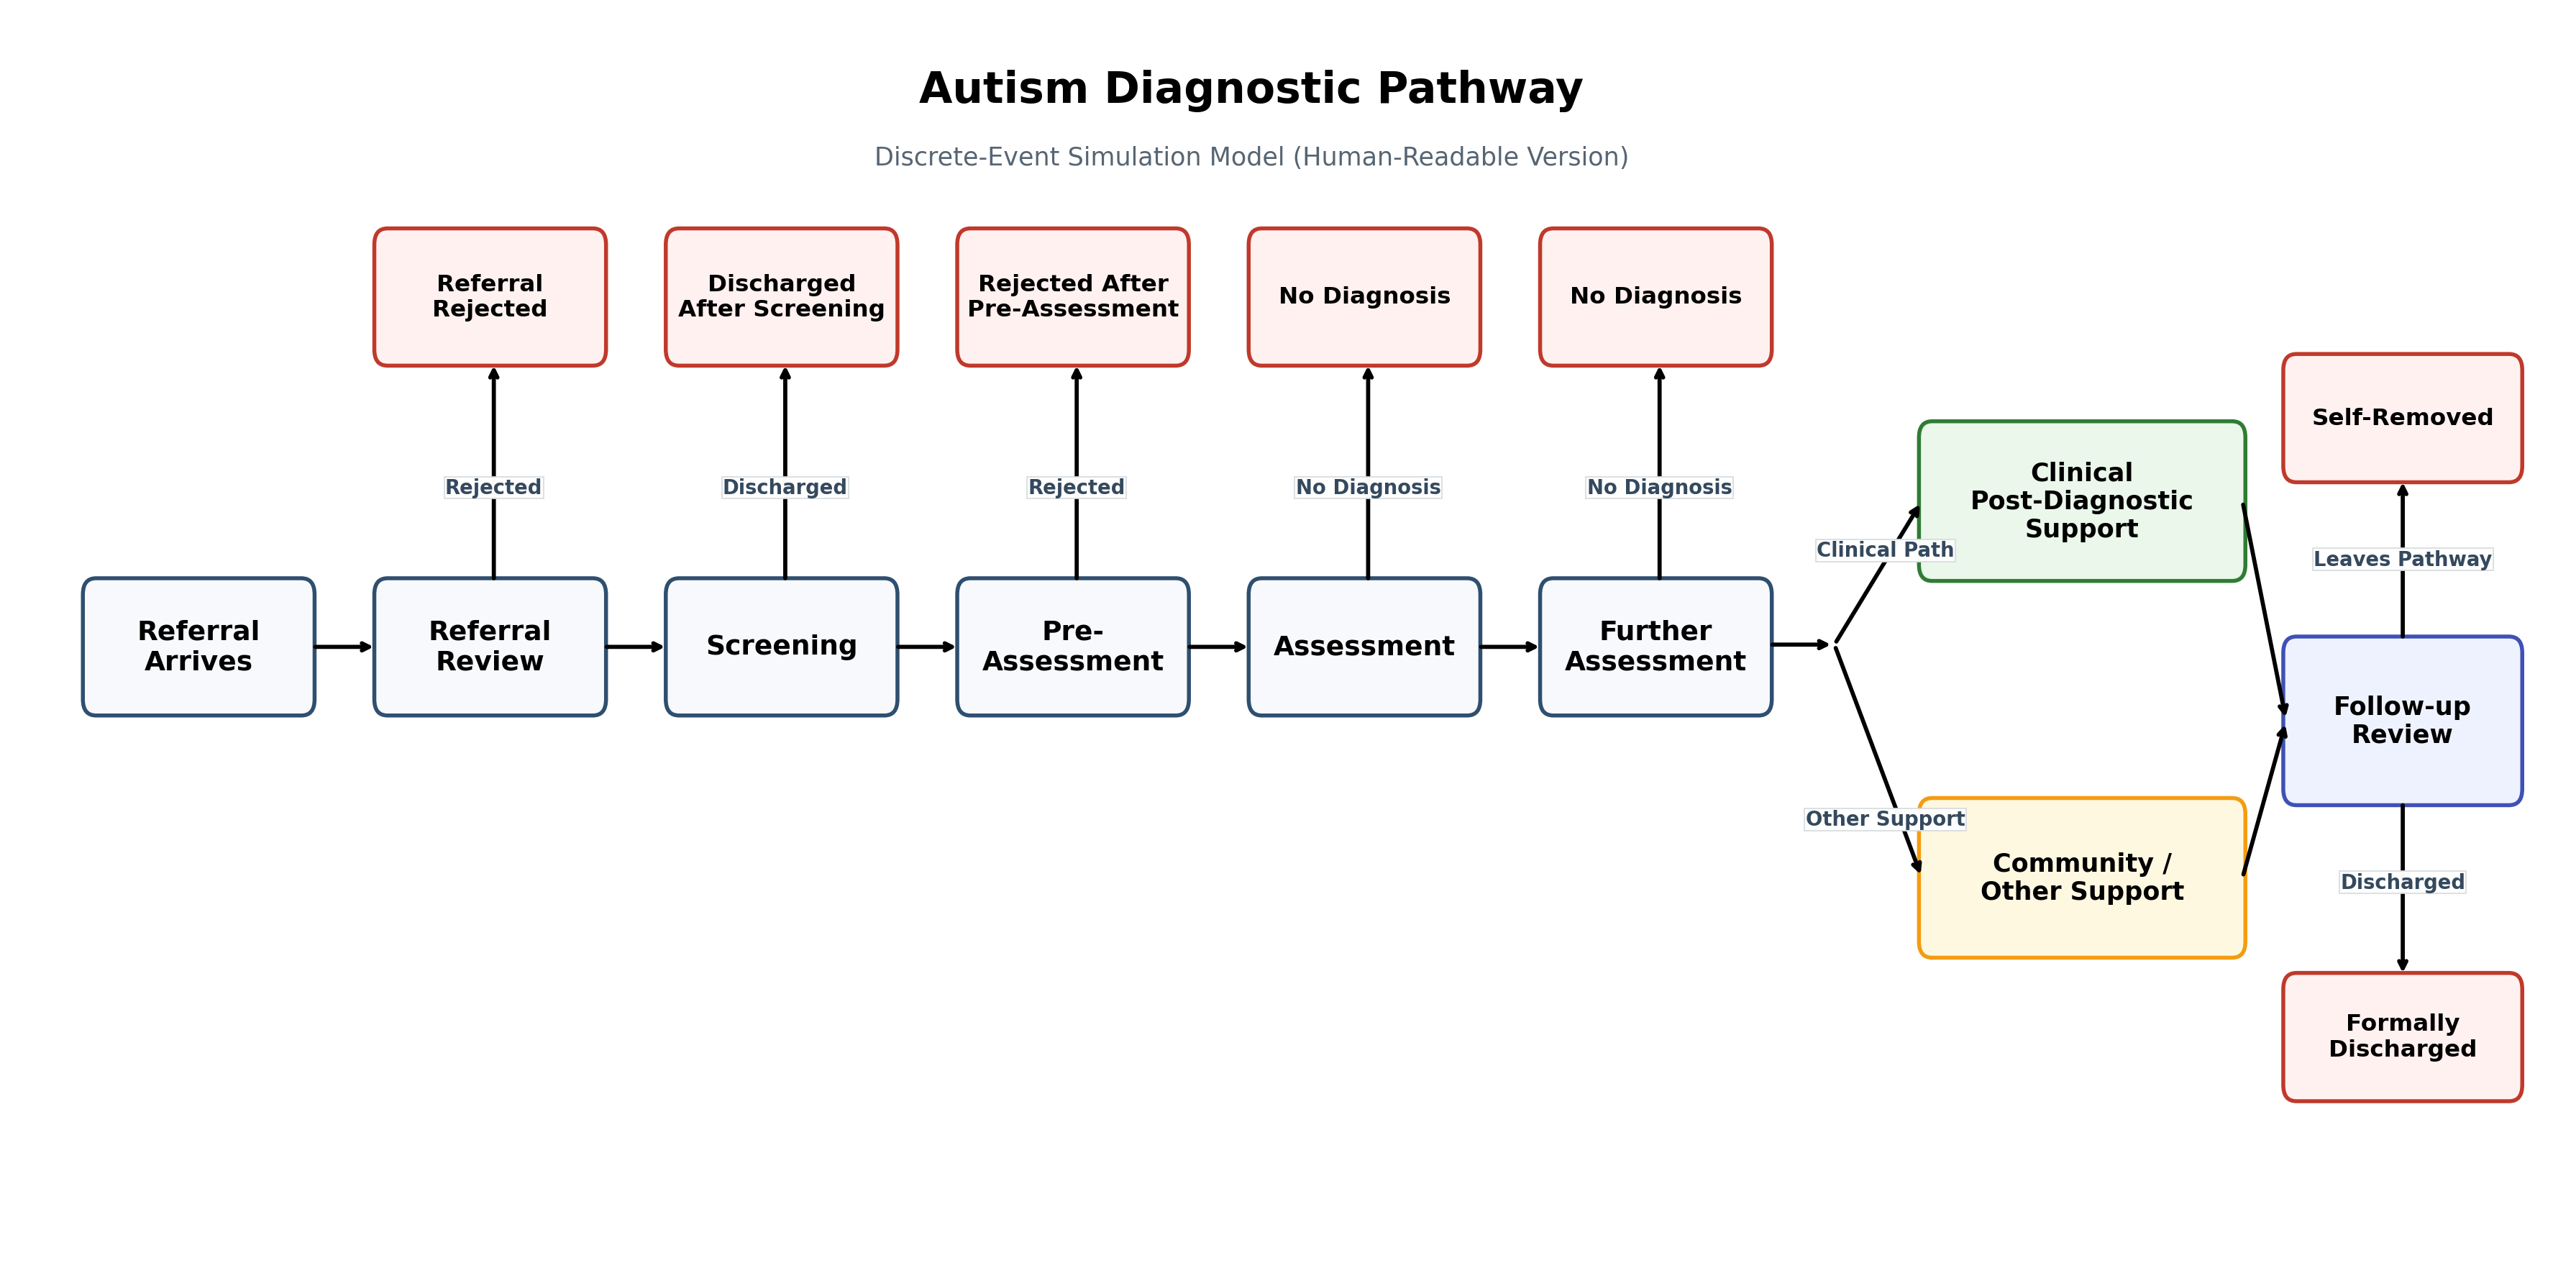

Saved to: figures/iteration2_model_pathway_human_readable.png


In [182]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ============================================================
# OUTPUT LOCATION
# ============================================================
out_path = Path("figures/iteration2_model_pathway_human_readable.png")
out_path.parent.mkdir(parents=True, exist_ok=True)

# ============================================================
# FIGURE (medium size)
# ============================================================
fig, ax = plt.subplots(figsize=(20, 10), dpi=180)

ax.set_xlim(0, 35)
ax.set_ylim(0, 14)
ax.axis("off")


# ============================================================
# DRAWING HELPERS
# ============================================================
def box(
    x,
    y,
    w,
    h,
    text,
    fc="#F7F9FC",
    ec="#2F4F6F",
    lw=2.2,
    fs=15,
    weight="bold"
):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.04,rounding_size=0.18",
        facecolor=fc,
        edgecolor=ec,
        linewidth=lw,
    )

    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fs,
        fontweight=weight
    )


def arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            lw=2.3,
        ),
    )


def small_label(x, y, text):
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#34495E",
        bbox=dict(
            facecolor="white",
            edgecolor="#D6DBDF",
            linewidth=0.7,
            pad=0.6,
            alpha=0.98,
        ),
    )


# ============================================================
# MAIN PATHWAY
# ============================================================
w, h = 3.1, 1.45
y_main = 6.2

x = [1, 5, 9, 13, 17, 21]

main_labels = [
    "Referral\nArrives",
    "Referral\nReview",
    "Screening",
    "Pre-\nAssessment",
    "Assessment",
    "Further\nAssessment",
]

for xi, label_txt in zip(x, main_labels):
    box(
        xi,
        y_main,
        w,
        h,
        label_txt
    )

for i in range(len(x) - 1):
    arrow(
        x[i] + w,
        y_main + h / 2,
        x[i + 1],
        y_main + h / 2
    )


# ============================================================
# EXITS ABOVE STAGES
# ============================================================
y_top = 10.1

exit_boxes = [
    (5, "Referral\nRejected"),
    (9, "Discharged\nAfter Screening"),
    (13, "Rejected After\nPre-Assessment"),
    (17, "No Diagnosis"),
    (21, "No Diagnosis"),
]

for xi, txt in exit_boxes:
    box(
        xi,
        y_top,
        w,
        h,
        txt,
        fc="#FFF1F0",
        ec="#C0392B",
        fs=13
    )

# Exit arrows
arrow(6.6, 7.65, 6.6, 10.1)
small_label(6.6, 8.7, "Rejected")

arrow(10.6, 7.65, 10.6, 10.1)
small_label(10.6, 8.7, "Discharged")

arrow(14.6, 7.65, 14.6, 10.1)
small_label(14.6, 8.7, "Rejected")

arrow(18.6, 7.65, 18.6, 10.1)
small_label(18.6, 8.7, "No Diagnosis")

arrow(22.6, 7.65, 22.6, 10.1)
small_label(22.6, 8.7, "No Diagnosis")


# ============================================================
# POST-DIAGNOSTIC SUPPORT
# ============================================================
split_x = 25
split_y = 6.95

# Connection from Further Assessment
arrow(24.1, split_y, split_x, split_y)

# Clinical support
box(
    26.2,
    7.7,
    4.4,
    1.7,
    "Clinical\nPost-Diagnostic\nSupport",
    fc="#EAF7EA",
    ec="#2E7D32",
    fs=14
)

# Community/Other support
box(
    26.2,
    3.5,
    4.4,
    1.7,
    "Community /\nOther Support",
    fc="#FFF8E1",
    ec="#F39C12",
    fs=14
)

# Split arrows
arrow(split_x, split_y, 26.2, 8.55)
small_label(25.7, 8.0, "Clinical Path")

arrow(split_x, split_y, 26.2, 4.35)
small_label(25.7, 5.0, "Other Support")


# ============================================================
# REVIEW / DISCHARGE
# ============================================================
box(
    31.2,
    5.2,
    3.2,
    1.8,
    "Follow-up\nReview",
    fc="#EEF2FF",
    ec="#3F51B5",
    fs=14
)

arrow(30.6, 8.55, 31.2, 6.1)
arrow(30.6, 4.35, 31.2, 6.1)


# ============================================================
# FINAL EXITS
# ============================================================
box(
    31.2,
    8.8,
    3.2,
    1.35,
    "Self-Removed",
    fc="#FFF1F0",
    ec="#C0392B",
    fs=13
)

box(
    31.2,
    1.9,
    3.2,
    1.35,
    "Formally\nDischarged",
    fc="#FFF1F0",
    ec="#C0392B",
    fs=13
)

arrow(32.8, 7.0, 32.8, 8.8)
small_label(32.8, 7.9, "Leaves Pathway")

arrow(32.8, 5.2, 32.8, 3.25)
small_label(32.8, 4.3, "Discharged")


# ============================================================
# TITLES
# ============================================================
ax.text(
    17,
    13.0,
    "Autism Diagnostic Pathway",
    ha="center",
    fontsize=24,
    fontweight="bold"
)

ax.text(
    17,
    12.3,
    "Discrete-Event Simulation Model (Human-Readable Version)",
    ha="center",
    fontsize=14,
    color="#566573"
)

# ============================================================
# SAVE
# ============================================================
fig.tight_layout()

fig.savefig(
    out_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved to: {out_path}")

## 1. Imports



In [155]:
import simpy
import numpy as np
import matplotlib.pyplot as plt
import scipy
import itertools

from adhd_simpy.Model.distributions import (Exponential, 
                                            Triangular, 
                                            Uniform, 
                                            Bernoulli, 
                                            Poisson, 
                                            LogNormal)

## 2. Global Settings and NHS Targets

Global demand, durations, probabilities, staffing, and random stream settings.

In [156]:
# ============================================================
# GLOBAL SETTINGS
# ============================================================

TRACE = False
RUN_LENGTH = 365 * 5  # Total simulation horizon in days

# ============================================================
# DEMAND
# ============================================================
REFERRALS_PER_DAY = 5  # Average number of new referrals per day
IAT = 1.0 / REFERRALS_PER_DAY  # Mean inter-arrival time in days

# ============================================================
# STAGE DURATIONS (TRIANGULAR: MIN, MODE, MAX) IN HOURS
# Converted to days in Experiment.init_sampling()
# ============================================================
DURATION_SCREENING = [0.5, 0.75, 1.5]          # Screening contact duration
DURATION_PRE_ASSESSMENT = [1.0, 2.0, 3.0]      # Pre-assessment duration
DURATION_ASSESSMENT = [2.0, 3.0, 5.0]          # Full assessment duration
DURATION_FURTHER_ASSESSMENT = [1.5, 2.5, 4.0]  # Further assessment duration
DURATION_POST_DIAG_CLINICAL = [1.0, 1.5, 2.5]  # Clinical post-diagnostic support duration
DURATION_POST_DIAG_OTHER = [1.5, 2.5, 4.0]     # Non-clinical post-diagnostic support duration
DURATION_REVIEW = [0.25, 0.5, 1.0]             # Review/discharge duration

# ============================================================
# BRANCHING PROBABILITIES
# ============================================================
PCT_REFERRAL_REJECTED = 0.25                 # Probability referral is rejected at entry
PCT_SCREENING_DISCHARGED = 0.12              # Probability discharged after screening
PCT_PRE_ASS_REJECTED = 0.08                  # Probability rejected after pre-assessment
PCT_NON_DIAGNOSIS_AT_ASSESSMENT = 0.15       # Probability of non-diagnosis at first assessment
PCT_NON_DIAGNOSIS_AT_FURTHER_ASSESSMENT = 0.10  # Probability of non-diagnosis at further assessment
PCT_POST_DIAG_CLINICAL = 0.72                # Probability diagnosed patient goes to clinical support
PCT_REMOVAL_DISCHARGE = 0.88                 # Probability of formal discharge at review

# ============================================================
# STAFF CAPACITY (PARALLEL SLOTS)
# ============================================================
STAFF_SCREENING = 2         # Number of simultaneous screening slots
STAFF_PRE_ASSESSMENT = 3    # Number of simultaneous pre-assessment slots
STAFF_ASSESSMENT = 5        # Number of simultaneous assessment slots
STAFF_FURTHER_ASSESSMENT = 3  # Number of simultaneous further-assessment slots
STAFF_POST_DIAG_CLINICAL = 4  # Number of simultaneous clinical support slots
STAFF_POST_DIAG_OTHER = 2      # Number of simultaneous non-clinical support slots
STAFF_REVIEW = 2               # Number of simultaneous review/discharge slots

# ============================================================
# RANDOM NUMBER SETTINGS
# ============================================================
N_STREAMS = 20       # Number of independent random streams
DEFAULT_RND_SET = 0  # Base random seed set index


## 3. Parameter Meanings

This section explains what each model parameter means.

### 3.1 Core Controls

- `TRACE`: Turns detailed event logging on or off.
- `RUN_LENGTH`: Total simulation horizon in **days**.

### 3.2 Demand

- `REFERRALS_PER_DAY`: Average new referrals entering the pathway per day.
- `IAT`: Mean inter-arrival time (`1 / REFERRALS_PER_DAY`).

### 3.3 Stage Durations (Hours, Triangular: Min/Mode/Max)

- `DURATION_SCREENING`: Initial screening contact duration.
- `DURATION_PRE_ASSESSMENT`: Pre-assessment review duration.
- `DURATION_ASSESSMENT`: Full diagnostic assessment duration.
- `DURATION_FURTHER_ASSESSMENT`: Extended/specialist assessment duration.
- `DURATION_POST_DIAG_CLINICAL`: Clinical post-diagnostic support duration.
- `DURATION_POST_DIAG_OTHER`: Non-clinical post-diagnostic support duration.
- `DURATION_REVIEW`: Final review/removal/discharge duration.

### 3.4 Gatekeeping and Branching Probabilities

- `PCT_REFERRAL_REJECTED`: Referral rejection probability at entry.
- `PCT_SCREENING_DISCHARGED`: Discharge probability after screening.
- `PCT_PRE_ASS_REJECTED`: Non-progression probability after pre-assessment.
- `PCT_NON_DIAGNOSIS_AT_ASSESSMENT`: Non-diagnosis probability at first assessment.
- `PCT_NON_DIAGNOSIS_AT_FURTHER_ASSESSMENT`: Non-diagnosis probability at further assessment.
- `PCT_POST_DIAG_CLINICAL`: Probability of clinical post-diagnostic route.
- `PCT_REMOVAL_DISCHARGE`: Probability of formal discharge at review.

### 3.5 Staffing (Parallel Capacity)

- `STAFF_SCREENING`: Concurrent screening slots.
- `STAFF_PRE_ASSESSMENT`: Concurrent pre-assessment slots.
- `STAFF_ASSESSMENT`: Concurrent assessment slots.
- `STAFF_FURTHER_ASSESSMENT`: Concurrent further-assessment slots.
- `STAFF_POST_DIAG_CLINICAL`: Concurrent clinical support slots.
- `STAFF_POST_DIAG_OTHER`: Concurrent non-clinical support slots.
- `STAFF_REVIEW`: Concurrent review/discharge slots.

### 3.6 Simulation Randomness

- `N_STREAMS`: Number of independent random streams.
- `DEFAULT_RND_SET`: Base seed set for reproducibility.

## 4. Trace Utility

Utility function for optional event-level logging.

In [157]:
def trace(msg: str) -> None:
    """Conditionally print debug output for event-level tracing.

    This helper keeps logging logic centralized so the simulation code
    can stay readable while still supporting detailed step-by-step output.

    Args:
        msg: Message describing a simulation event.
    """
    if TRACE:
        print(msg)

## 5. Audit Class

Placeholder audit/data collection class for model outputs.

In [158]:
# ============================================================
# AUDIT CLASS FOR DATA COLLECTION
# ============================================================

class Audit:
   def __init__(self):
        pass

## 6. Experiment Setup

Parameter container, sampling initialization, and KPI dictionary setup.

In [159]:
# ============================================================
# EXPERIMENT SETUP
# ============================================================
class Experiment:
    def __init__(self,
                 auditor,
                 random_number_set=DEFAULT_RND_SET,
                 n_streams=N_STREAMS,
                 iat=IAT,
                 # Gatekeeping probabilities
                 traige_rejected=PCT_REFERRAL_REJECTED,
                 screening_discharge=PCT_SCREENING_DISCHARGED,
                 pre_assessment_rejection=PCT_PRE_ASS_REJECTED,
                 # Assessment outcome splits
                 pct_non_diag_at_assessment=PCT_NON_DIAGNOSIS_AT_ASSESSMENT,
                 pct_non_diag_at_further_assessment=PCT_NON_DIAGNOSIS_AT_FURTHER_ASSESSMENT,
                 # Post-diagnostic pathway
                 pct_post_diag_clinical=PCT_POST_DIAG_CLINICAL,
                 pct_removal_discharge=PCT_REMOVAL_DISCHARGE,
                 # Durations
                 dur_screening=DURATION_SCREENING,
                 dur_pre_assessment=DURATION_PRE_ASSESSMENT,
                 dur_assessment=DURATION_ASSESSMENT,
                 dur_further_assessment=DURATION_FURTHER_ASSESSMENT,
                 dur_post_diag_clinical=DURATION_POST_DIAG_CLINICAL,
                 dur_post_diag_other=DURATION_POST_DIAG_OTHER,
                 dur_review=DURATION_REVIEW,
                 # Staff / capacity
                 staff_screening=STAFF_SCREENING,
                 staff_pre_assessment=STAFF_PRE_ASSESSMENT,
                 staff_assessment=STAFF_ASSESSMENT,
                 staff_further_assessment=STAFF_FURTHER_ASSESSMENT,
                 staff_post_diag_clinical=STAFF_POST_DIAG_CLINICAL,
                 staff_post_diag_other=STAFF_POST_DIAG_OTHER,
                 staff_review=STAFF_REVIEW,
                 ):
        self.auditor = auditor
        self.random_number_set = random_number_set
        self.n_streams = n_streams

        # Demand
        self.iat = iat

        # Gatekeeping probabilities
        self.traige_rejected = traige_rejected
        self.screening_discharge = screening_discharge
        self.pre_assessment_rejection = pre_assessment_rejection

        # Assessment & further assessment outcome splits
        self.pct_non_diag_at_assessment = pct_non_diag_at_assessment
        self.pct_non_diag_at_further_assessment = pct_non_diag_at_further_assessment

        # Post-diagnostic pathway
        self.pct_post_diag_clinical = pct_post_diag_clinical
        self.pct_removal_discharge = pct_removal_discharge

        # Duration parameters (hours – converted to days inside init_sampling)
        self.dur_screening = dur_screening
        self.dur_pre_assessment = dur_pre_assessment
        self.dur_assessment = dur_assessment
        self.dur_further_assessment = dur_further_assessment
        self.dur_post_diag_clinical = dur_post_diag_clinical
        self.dur_post_diag_other = dur_post_diag_other
        self.dur_review = dur_review

        # Staff / capacity
        self.staff_screening = staff_screening
        self.staff_pre_assessment = staff_pre_assessment
        self.staff_assessment = staff_assessment
        self.staff_further_assessment = staff_further_assessment
        self.staff_post_diag_clinical = staff_post_diag_clinical
        self.staff_post_diag_other = staff_post_diag_other
        self.staff_review = staff_review

        self.init_results_variables()
        self.init_sampling()

    def set_random_no_set(self, random_number_set):
        self.random_number_set = random_number_set
        self.init_sampling()

    def init_sampling(self):
        seed_sequence = np.random.SeedSequence(self.random_number_set)
        self.seeds = seed_sequence.spawn(self.n_streams)

        def to_days(hours_list):
            return [h / 24.0 for h in hours_list]

        # 0) Inter-arrival time (Exponential)
        self.iat_dist = Exponential(self.iat, random_seed=self.seeds[0])

        # 1) Screening duration (Triangular)
        self.screening_time_dist = Triangular(*to_days(self.dur_screening),
                                              random_seed=self.seeds[1])
        # 2) Pre-assessment duration (Triangular)
        self.pre_ass_time_dist = Triangular(*to_days(self.dur_pre_assessment),
                                            random_seed=self.seeds[2])
        # 3) Assessment duration (Triangular)
        self.assessment_time_dist = Triangular(*to_days(self.dur_assessment),
                                               random_seed=self.seeds[3])
        # 4) Referral rejection (Bernoulli)
        self.referral_reject_dist = Bernoulli(self.traige_rejected,
                                              random_seed=self.seeds[4])
        # 5) Screening discharge (Bernoulli)
        self.screening_discharge_dist = Bernoulli(self.screening_discharge,
                                                  random_seed=self.seeds[5])
        # 6) Pre-assessment rejection (Bernoulli)
        self.pre_ass_reject_dist = Bernoulli(self.pre_assessment_rejection,
                                             random_seed=self.seeds[6])
        # 7) Non-diagnosis at assessment (Bernoulli)
        self.non_diag_at_assessment_dist = Bernoulli(self.pct_non_diag_at_assessment,
                                                     random_seed=self.seeds[7])
        # 8) Further assessment duration (Triangular)
        self.further_assessment_time_dist = Triangular(*to_days(self.dur_further_assessment),
                                                       random_seed=self.seeds[8])
        # 9) Non-diagnosis at further assessment (Bernoulli)
        self.non_diag_at_further_assessment_dist = Bernoulli(
            self.pct_non_diag_at_further_assessment, random_seed=self.seeds[9])

        # 10) Post-diagnostic clinical split (Bernoulli)
        self.post_diag_clinical_dist = Bernoulli(self.pct_post_diag_clinical,
                                                 random_seed=self.seeds[10])
        # 11) Post-diagnostic clinical duration (Triangular)
        self.post_diag_clinical_time_dist = Triangular(*to_days(self.dur_post_diag_clinical),
                                                       random_seed=self.seeds[11])
        # 12) Post-diagnostic other duration (Triangular)
        self.post_diag_other_time_dist = Triangular(*to_days(self.dur_post_diag_other),
                                                    random_seed=self.seeds[12])
        # 13) Review / removal duration (Triangular)
        self.review_time_dist = Triangular(*to_days(self.dur_review),
                                           random_seed=self.seeds[13])
        # 14) Removal / discharge decision (Bernoulli)
        self.removal_discharge_dist = Bernoulli(self.pct_removal_discharge,
                                                random_seed=self.seeds[14])

    def init_results_variables(self):
        self.results = {
            # ================================================
            # OVERALL FLOW
            # ================================================
            "N_REFERRALS_ARRIVED": 0,
            "N_EXITED_TOTAL": 0,
            "N_COMPLETED": 0,
            "N_IN_SYSTEM_END": 0,

            # ================================================
            # REFERRAL TRIAGE
            # ================================================
            "N_REF_ACCEPTED": 0,
            "N_REF_REJECTED": 0,

            # ================================================
            # SCREENING
            # ================================================
            "N_SCREENING_ACCEPTED": 0,
            "N_SCREENING_COMPLETED": 0,
            "N_SCREENING_DISCHARGED": 0,

            # ================================================
            # PRE-ASSESSMENT
            # ================================================
            "N_PRE_ASSESS_ACCEPTED": 0,
            "N_PRE_ASSESS_COMPLETED": 0,
            "N_PRE_ASSESS_REJECTED": 0,

            # ================================================
            # ASSESSMENT
            # ================================================
            "N_ASSESSMENT_ACCEPTED": 0,
            "N_ASSESSMENT_COMPLETED": 0,
            "N_NON_DIAGNOSIS_ASSESSMENT": 0,

            # ================================================
            # FURTHER ASSESSMENT
            # ================================================
            "N_FURTHER_ASSESS_ACCEPTED": 0,
            "N_FURTHER_ASSESS_COMPLETED": 0,
            "N_NON_DIAGNOSIS_FURTHER_ASSESSMENT": 0,

            # ================================================
            # DIAGNOSTIC OUTCOME
            # ================================================
            "N_DIAGNOSIS_TOTAL": 0,

            # ================================================
            # POST-DIAGNOSTIC SUPPORT
            # ================================================
            "N_POST_DIAG_CLINICAL_ACCEPTED": 0,
            "N_POST_DIAG_CLINICAL_COMPLETED": 0,
            "N_POST_DIAG_OTHER_ACCEPTED": 0,
            "N_POST_DIAG_OTHER_COMPLETED": 0,

            # ================================================
            # REMOVAL / DISCHARGE
            # ================================================
            "N_REMOVAL_DISCHARGE": 0,
            "N_SELF_REMOVED": 0,
        }


## 7. Patient Pathway Logic

Stage-by-stage patient flow, queueing, branching, and exits.

In [160]:
class Patient:
    def __init__(self, patient_id, system):
        self.patient_id = patient_id
        self.system = system
        self.env = system.env
        self.args = system.args

    def process(self):
        self.args["N_REFERRALS_ARRIVED"] += 1

        # ============================================================
        # REFERRAL TRIAGE
        # ============================================================
        if self.system.referral_reject_dist.sample() == 1:
            self.args["N_REF_REJECTED"] += 1
            self.args["N_EXITED_TOTAL"] += 1
            trace(f"Patient {self.patient_id} rejected at referral triage.")
            return

        self.args["N_REF_ACCEPTED"] += 1
        trace(f"Patient {self.patient_id} accepted into pathway.")

        # ============================================================
        # SCREENING
        # ============================================================
        self.args["N_SCREENING_ACCEPTED"] += 1
        before_screening = self.env.now
        with self.system.screening_resource.request() as req:
            yield req
            screening_waited_time = self.env.now - before_screening
            trace(f"Patient {self.patient_id} started screening "
                  f"(waited {screening_waited_time:.2f} days).")
            screening_duration = self.system.screening_time_dist.sample()
            yield self.env.timeout(screening_duration)
            self.args["N_SCREENING_COMPLETED"] += 1
            trace(f"Patient {self.patient_id} completed screening "
                  f"(duration {screening_duration:.2f} days).")

        if self.system.screening_discharge_dist.sample() == 1:
            self.args["N_SCREENING_DISCHARGED"] += 1
            self.args["N_EXITED_TOTAL"] += 1
            trace(f"Patient {self.patient_id} discharged after screening.")
            return

        # ============================================================
        # PRE-ASSESSMENT
        # ============================================================
        self.args["N_PRE_ASSESS_ACCEPTED"] += 1
        before_pre_assessment = self.env.now
        with self.system.pre_assessment_resource.request() as req:
            yield req
            pre_assessment_waited_time = self.env.now - before_pre_assessment
            trace(f"Patient {self.patient_id} started pre-assessment "
                  f"(waited {pre_assessment_waited_time:.2f} days).")
            pre_assessment_duration = self.system.pre_ass_time_dist.sample()
            yield self.env.timeout(pre_assessment_duration)
            self.args["N_PRE_ASSESS_COMPLETED"] += 1
            trace(f"Patient {self.patient_id} completed pre-assessment "
                  f"(duration {pre_assessment_duration:.2f} days).")

        if self.system.pre_ass_reject_dist.sample() == 1:
            self.args["N_PRE_ASSESS_REJECTED"] += 1
            self.args["N_EXITED_TOTAL"] += 1
            trace(f"Patient {self.patient_id} rejected after pre-assessment.")
            return

        # ============================================================
        # ASSESSMENT
        # ============================================================
        self.args["N_ASSESSMENT_ACCEPTED"] += 1
        before_assessment = self.env.now
        with self.system.assessment_resource.request() as req:
            yield req
            assessment_waited_time = self.env.now - before_assessment
            trace(f"Patient {self.patient_id} started assessment "
                  f"(waited {assessment_waited_time:.2f} days).")
            assessment_duration = self.system.assessment_time_dist.sample()
            yield self.env.timeout(assessment_duration)
            self.args["N_ASSESSMENT_COMPLETED"] += 1
            trace(f"Patient {self.patient_id} completed assessment "
                  f"(duration {assessment_duration:.2f} days).")

        if self.system.non_diag_at_assessment_dist.sample() == 1:
            self.args["N_NON_DIAGNOSIS_ASSESSMENT"] += 1
            self.args["N_EXITED_TOTAL"] += 1
            trace(f"Patient {self.patient_id}: non-diagnosis at assessment, exiting.")
            return

        # ============================================================
        # FURTHER ASSESSMENT
        # ============================================================
        self.args["N_FURTHER_ASSESS_ACCEPTED"] += 1
        before_further = self.env.now
        with self.system.further_assessment_resource.request() as req:
            yield req
            further_waited_time = self.env.now - before_further
            trace(f"Patient {self.patient_id} started further assessment "
                  f"(waited {further_waited_time:.2f} days).")
            further_duration = self.system.further_assessment_time_dist.sample()
            yield self.env.timeout(further_duration)
            self.args["N_FURTHER_ASSESS_COMPLETED"] += 1
            trace(f"Patient {self.patient_id} completed further assessment "
                  f"(duration {further_duration:.2f} days).")

        if self.system.non_diag_at_further_assessment_dist.sample() == 1:
            self.args["N_NON_DIAGNOSIS_FURTHER_ASSESSMENT"] += 1
            self.args["N_EXITED_TOTAL"] += 1
            trace(f"Patient {self.patient_id}: non-diagnosis at further assessment, exiting.")
            return

        # Diagnosis confirmed
        self.args["N_DIAGNOSIS_TOTAL"] += 1
        trace(f"Patient {self.patient_id} received a confirmed diagnosis.")

        # ============================================================
        # POST-DIAGNOSTIC SUPPORT
        # ============================================================
        if self.system.post_diag_clinical_dist.sample() == 1:
            # Clinical pathway
            self.args["N_POST_DIAG_CLINICAL_ACCEPTED"] += 1
            before_clinical = self.env.now
            with self.system.post_diag_clinical_resource.request() as req:
                yield req
                clinical_waited_time = self.env.now - before_clinical
                trace(f"Patient {self.patient_id} started clinical post-diagnostic support "
                      f"(waited {clinical_waited_time:.2f} days).")
                clinical_duration = self.system.post_diag_clinical_time_dist.sample()
                yield self.env.timeout(clinical_duration)
                self.args["N_POST_DIAG_CLINICAL_COMPLETED"] += 1
                trace(f"Patient {self.patient_id} completed clinical post-diagnostic support "
                      f"(duration {clinical_duration:.2f} days).")
        else:
            # Other pathway
            self.args["N_POST_DIAG_OTHER_ACCEPTED"] += 1
            before_other = self.env.now
            with self.system.post_diag_other_resource.request() as req:
                yield req
                other_waited_time = self.env.now - before_other
                trace(f"Patient {self.patient_id} started other post-diagnostic support "
                      f"(waited {other_waited_time:.2f} days).")
                other_duration = self.system.post_diag_other_time_dist.sample()
                yield self.env.timeout(other_duration)
                self.args["N_POST_DIAG_OTHER_COMPLETED"] += 1
                trace(f"Patient {self.patient_id} completed other post-diagnostic support "
                      f"(duration {other_duration:.2f} days).")

        # ============================================================
        # REMOVAL / DISCHARGE REVIEW
        # ============================================================
        before_review = self.env.now
        with self.system.review_resource.request() as req:
            yield req
            review_waited_time = self.env.now - before_review
            trace(f"Patient {self.patient_id} started removal/discharge review "
                  f"(waited {review_waited_time:.2f} days).")
            review_duration = self.system.review_time_dist.sample()
            yield self.env.timeout(review_duration)
            trace(f"Patient {self.patient_id} completed removal/discharge review "
                  f"(duration {review_duration:.2f} days).")

        if self.system.removal_discharge_dist.sample() == 1:
            self.args["N_REMOVAL_DISCHARGE"] += 1
            trace(f"Patient {self.patient_id} formally discharged.")
        else:
            self.args["N_SELF_REMOVED"] += 1
            trace(f"Patient {self.patient_id} self-removed from pathway.")

        self.args["N_COMPLETED"] += 1
        self.args["N_EXITED_TOTAL"] += 1


## 8. System Resource Setup

System class wiring distributions, resources, and patient generation.

In [166]:
class AutismPathwaySystem:
    def __init__(self, env, experiment):
        self.env = env
        self.experiment = experiment
        self.args = experiment.results
        self.active_patients_list = []

        # Distributions and RNG streams from experiment
        self.iat_dist = experiment.iat_dist
        self.screening_time_dist = experiment.screening_time_dist
        self.pre_ass_time_dist = experiment.pre_ass_time_dist
        self.assessment_time_dist = experiment.assessment_time_dist
        self.referral_reject_dist = experiment.referral_reject_dist
        self.screening_discharge_dist = experiment.screening_discharge_dist
        self.pre_ass_reject_dist = experiment.pre_ass_reject_dist
        self.non_diag_at_assessment_dist = experiment.non_diag_at_assessment_dist
        self.further_assessment_time_dist = experiment.further_assessment_time_dist
        self.non_diag_at_further_assessment_dist = experiment.non_diag_at_further_assessment_dist
        self.post_diag_clinical_dist = experiment.post_diag_clinical_dist
        self.post_diag_clinical_time_dist = experiment.post_diag_clinical_time_dist
        self.post_diag_other_time_dist = experiment.post_diag_other_time_dist
        self.review_time_dist = experiment.review_time_dist
        self.removal_discharge_dist = experiment.removal_discharge_dist

        # Staff resources sourced from experiment parameters
        self.screening_resource = simpy.Resource(env, capacity=experiment.staff_screening)
        self.pre_assessment_resource = simpy.Resource(env, capacity=experiment.staff_pre_assessment)
        self.assessment_resource = simpy.Resource(env, capacity=experiment.staff_assessment)
        self.further_assessment_resource = simpy.Resource(env, capacity=experiment.staff_further_assessment)
        self.post_diag_clinical_resource = simpy.Resource(env, capacity=experiment.staff_post_diag_clinical)
        self.post_diag_other_resource = simpy.Resource(env, capacity=experiment.staff_post_diag_other)
        self.review_resource = simpy.Resource(env, capacity=experiment.staff_review)

        # Start arrival generator process
        self.env.process(self.generate_patients())

    def generate_patients(self):
        for patient_id in itertools.count(1):
            inter_arrival_time = self.iat_dist.sample()
            yield self.env.timeout(inter_arrival_time)

            new_patient = Patient(patient_id, self)
            self.env.process(new_patient.process())
            self.active_patients_list.append(new_patient)

            trace(
                f"Patient {patient_id} arrived at time {self.env.now:.2f} days."
            )


## 9. Single Run Function

Run one replication and return results.

In [162]:
def single_run(experiment, rep=0, run_length=RUN_LENGTH):
    """
    Perform a single run of the model and return the results.

    Parameters
    ----------
    experiment : Experiment
        The experiment/parameters to use with model
    rep : int
        The replication number (used to set random seeds).
    run_length : float
        The run length of the model in days (default = the constant set).
    """
    # 1. Reset results for each run
    experiment.init_results_variables()

    # 2. Set the random number set for this run
    experiment.set_random_no_set(rep)

    # 3. Create a fresh environment and a pathway system
    env = simpy.Environment()
    AutismPathwaySystem(env, experiment)

    # 4. Run the simulation
    env.run(until=run_length)
    trace(f"Rep {rep}: Simulation run completed.")

    # 5. End-of-run inventory check
    experiment.results["N_IN_SYSTEM_END"] = (
        experiment.results["N_REFERRALS_ARRIVED"] - experiment.results["N_EXITED_TOTAL"]
    )

    # 6. Collect results from the experiment results dict
    results = experiment.results.copy()
    return results

## 10. Quick Trace Test Run

Short run with tracing enabled for event-level verification.

In [167]:
# Run a single replication for testing
TRACE = True
run_time = 3# 1 day for quick test run
experiment1 = Experiment(auditor=Audit())
results = single_run(experiment1, rep=0, run_length=run_time)

Patient 1 arrived at time 0.66 days.
Patient 1 accepted into pathway.
Patient 1 started screening (waited 0.00 days).
Patient 1 completed screening (duration 0.04 days).
Patient 1 started pre-assessment (waited 0.00 days).
Patient 1 completed pre-assessment (duration 0.10 days).
Patient 1 started assessment (waited 0.00 days).
Patient 2 arrived at time 0.81 days.
Patient 2 accepted into pathway.
Patient 2 started screening (waited 0.00 days).
Patient 2 completed screening (duration 0.03 days).
Patient 2 started pre-assessment (waited 0.00 days).
Patient 2 completed pre-assessment (duration 0.06 days).
Patient 2 started assessment (waited 0.00 days).
Patient 1 completed assessment (duration 0.13 days).
Patient 1 started further assessment (waited 0.00 days).
Patient 2 completed assessment (duration 0.14 days).
Patient 2 started further assessment (waited 0.00 days).
Patient 1 completed further assessment (duration 0.13 days).
Patient 1 received a confirmed diagnosis.
Patient 1 started o

## 11. Main Results Run

Primary run for summary KPI output.

In [164]:
# Run a single replication for testing
TRACE = False
experiment2 = Experiment(auditor=Audit())
results = single_run(experiment2, rep=0, run_length=RUN_LENGTH)

print(f"{'='*52}")
print(f"  Simulation Results  |  Run length: {RUN_LENGTH} days")
print(f"{'='*52}")
print(f"  REFERRAL TRIAGE")
print(f"    Arrived                        : {results['N_REFERRALS_ARRIVED']}")
print(f"    Rejected at triage             : {results['N_REF_REJECTED']}")
print(f"    Accepted into pathway          : {results['N_REF_ACCEPTED']}")
print(f"  SCREENING")
print(f"    Completed screening            : {results['N_SCREENING_COMPLETED']}")
print(f"    Discharged after screening     : {results['N_SCREENING_DISCHARGED']}")
print(f"  PRE-ASSESSMENT")
print(f"    Completed pre-assessment       : {results['N_PRE_ASSESS_COMPLETED']}")
print(f"    Rejected at pre-assessment     : {results['N_PRE_ASSESS_REJECTED']}")
print(f"  ASSESSMENT")
print(f"    Completed assessment           : {results['N_ASSESSMENT_COMPLETED']}")
print(f"    Non-diagnosis at assessment    : {results['N_NON_DIAGNOSIS_ASSESSMENT']}")
print(f"  FURTHER ASSESSMENT")
print(f"    Entered further assessment     : {results['N_FURTHER_ASSESS_ACCEPTED']}")
print(f"    Completed further assessment   : {results['N_FURTHER_ASSESS_COMPLETED']}")
print(f"    Non-diagnosis at further ass.  : {results['N_NON_DIAGNOSIS_FURTHER_ASSESSMENT']}")
print(f"  DIAGNOSTIC OUTCOME")
print(f"    Confirmed diagnoses            : {results['N_DIAGNOSIS_TOTAL']}")
print(f"  POST-DIAGNOSTIC SUPPORT")
print(f"    Clinical pathway               : {results['N_POST_DIAG_CLINICAL_ACCEPTED']}")
print(f"    Other pathway                  : {results['N_POST_DIAG_OTHER_ACCEPTED']}")
print(f"  REMOVAL / DISCHARGE")
print(f"    Formally discharged            : {results['N_REMOVAL_DISCHARGE']}")
print(f"    Self-removed                   : {results['N_SELF_REMOVED']}")
print(f"{'='*52}")
print(f"  Completed full pathway           : {results['N_COMPLETED']}")
print(f"  Still in system (end of run)     : {results['N_IN_SYSTEM_END']}")
print(f"{'='*52}")


  Simulation Results  |  Run length: 1825 days
  REFERRAL TRIAGE
    Arrived                        : 9294
    Rejected at triage             : 2280
    Accepted into pathway          : 7014
  SCREENING
    Completed screening            : 7014
    Discharged after screening     : 836
  PRE-ASSESSMENT
    Completed pre-assessment       : 6178
    Rejected at pre-assessment     : 519
  ASSESSMENT
    Completed assessment           : 5657
    Non-diagnosis at assessment    : 859
  FURTHER ASSESSMENT
    Entered further assessment     : 4798
    Completed further assessment   : 4798
    Non-diagnosis at further ass.  : 491
  DIAGNOSTIC OUTCOME
    Confirmed diagnoses            : 4307
  POST-DIAGNOSTIC SUPPORT
    Clinical pathway               : 3103
    Other pathway                  : 1204
  REMOVAL / DISCHARGE
    Formally discharged            : 3771
    Self-removed                   : 536
  Completed full pathway           : 4307
  Still in system (end of run)     : 2


## 12. 100% Triage Rejection Test

Sanity test where all referrals are rejected at triage.

In [165]:
# TESTING: increase referral rejection to 100%
# Expected: every arrival is rejected at triage; nothing progresses to screening or beyond.

TRACE = False

experiment = Experiment(auditor=Audit(), traige_rejected=1.0)
results = single_run(experiment, rep=0, run_length=RUN_LENGTH)

print("=== 100% Triage Rejection Test ===")
print(f"Total arrivals          : {results['N_REFERRALS_ARRIVED']}")
print(f"Rejected at triage      : {results['N_REF_REJECTED']}")
print(f"Accepted past triage    : {results['N_REF_ACCEPTED']}")
print(f"Entered screening       : {results['N_SCREENING_ACCEPTED']}")
print(f"Entered pre-assessment  : {results['N_PRE_ASSESS_ACCEPTED']}")
print(f"Entered assessment      : {results['N_ASSESSMENT_ACCEPTED']}")
print(f"Completed pathway       : {results['N_COMPLETED']}")
print()

# Assertions
assert results["N_REF_REJECTED"] == results["N_REFERRALS_ARRIVED"], \
    "FAIL: not all referrals were rejected"
assert results["N_REF_ACCEPTED"] == 0, \
    "FAIL: some referrals were accepted past triage"
assert results["N_SCREENING_ACCEPTED"] == 0, \
    "FAIL: patients reached screening"
assert results["N_PRE_ASSESS_ACCEPTED"] == 0, \
    "FAIL: patients reached pre-assessment"
assert results["N_ASSESSMENT_ACCEPTED"] == 0, \
    "FAIL: patients reached assessment"
assert results["N_COMPLETED"] == 0, \
    "FAIL: patients completed the pathway"

print("All assertions passed: 100% triage rejection behaves correctly.")


=== 100% Triage Rejection Test ===
Total arrivals          : 9294
Rejected at triage      : 9294
Accepted past triage    : 0
Entered screening       : 0
Entered pre-assessment  : 0
Entered assessment      : 0
Completed pathway       : 0

All assertions passed: 100% triage rejection behaves correctly.
